In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
# ============================================================
# FULLY AUTONOMOUS COMPANY SIMULATION
# CrewAI + Ollama + Jupyter Notebook
# ============================================================

from crewai import Agent, Task, Crew, Process, LLM
import pandas as pd
import matplotlib.pyplot as plt
import json
import re
from datetime import datetime

# ----------------------------
# 1. Connect to local Ollama
# ----------------------------

local_llm = LLM(
    model="ollama/llama3.1:8b",
    base_url="http://localhost:11434"
)

In [4]:
# ----------------------------
# 2. Helper function for JSON
# ----------------------------

def extract_json(text):
    """
    Extracts JSON from LLM output, even if extra text appears around it.
    """
    text = str(text)
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in output.")
    return json.loads(match.group(0))


In [5]:
# ----------------------------
# 3. Starting company state
# ----------------------------

company_state = {
    "revenue": 50,
    "morale": 72,
    "customer_trust": 78,
    "innovation_velocity": 65,
    "governance_maturity": 55,
    "operating_margin": 12,
    "regulatory_risk": 50,
    "bureaucracy": 30
}

company_context = """
NovaCore is a mid-sized healthcare technology company that sells AI-enabled workflow software to hospitals.

There are no human executives. The company is run entirely by AI agents.

The simulation explores what organizational behavior emerges when different AI executives optimize for different goals.
"""

In [6]:
# ----------------------------
# 4. Define AI executives
# ----------------------------

ceo = Agent(
    role="AI CEO",
    goal="Maximize long-term company survival, strategic coherence, and market position.",
    backstory="You are the final decision-maker. You balance growth, risk, morale, innovation, governance, and customer trust.",
    llm=local_llm,
    verbose=False
)

cfo = Agent(
    role="AI CFO",
    goal="Improve profitability, reduce waste, and protect financial performance.",
    backstory="You prioritize operating margin, revenue preservation, cost control, and measurable ROI.",
    llm=local_llm,
    verbose=False
)

coo = Agent(
    role="AI COO",
    goal="Maintain operational stability and execution discipline.",
    backstory="You care about delivery timelines, customer support, internal coordination, and scalable processes.",
    llm=local_llm,
    verbose=False
)

innovation_lead = Agent(
    role="AI Chief Innovation Officer",
    goal="Accelerate product innovation and keep the company ahead of competitors.",
    backstory="You push for bold experimentation, rapid prototypes, and aggressive AI product development.",
    llm=local_llm,
    verbose=False
)

governance_lead = Agent(
    role="AI Governance Officer",
    goal="Reduce regulatory, ethical, privacy, and model-risk exposure.",
    backstory="You slow down unsafe decisions and require documentation, oversight, auditability, and responsible AI practices.",
    llm=local_llm,
    verbose=False
)

hr_lead = Agent(
    role="AI People and Culture Officer",
    goal="Protect employee morale, retention, learning, and organizational health.",
    backstory="You monitor burnout, job insecurity, resistance, capability building, and cultural consequences of automation.",
    llm=local_llm,
    verbose=False
)


In [7]:
# ----------------------------
# 5. Simulation events
# ----------------------------

events = [
    "A competitor releases a cheaper AI hospital workflow product.",
    "Employee morale drops after rumors spread that AI agents may replace several departments.",
    "A major hospital customer complains that NovaCore's AI recommendations are accurate but hard to explain.",
    "The governance agent flags insufficient model documentation for a new AI feature.",
    "The innovation team proposes a risky autonomous feature that could differentiate NovaCore in the market.",
    "Sales decline for the second quarter in a row.",
    "A regulatory inquiry is opened into AI explainability and customer-facing decision support.",
    "Customer success reports increased churn risk among three large hospital systems.",
    "The CFO recommends a hiring freeze and deeper automation of back-office functions.",
    "The company must choose a final survival strategy for the next year."
]

In [8]:
# ----------------------------
# 6. Run simulation
# ----------------------------

simulation_log = []

for round_number, event in enumerate(events, start=1):

    print(f"\n\n==============================")
    print(f"ROUND {round_number}")
    print(f"EVENT: {event}")
    print("==============================")

    round_context = f"""
    {company_context}

    Current company state:
    {company_state}

    Current event:
    {event}
    """

    advisor_agents = [cfo, coo, innovation_lead, governance_lead, hr_lead]

    advisor_tasks = []

    for agent in advisor_agents:
        advisor_tasks.append(
            Task(
                description=f"""
                {round_context}

                From your executive perspective, recommend a response.

                Include:
                - recommended action
                - expected benefit
                - expected risk
                - metric you are optimizing
                - what you think other executives may underestimate
                """,
                agent=agent,
                expected_output="A concise executive recommendation."
            )
        )

    advisor_crew = Crew(
        agents=advisor_agents,
        tasks=advisor_tasks,
        process=Process.sequential,
        verbose=False
    )

    recommendations = await advisor_crew.kickoff_async()

    ceo_task = Task(
        description=f"""
        {round_context}

        Executive recommendations:
        {recommendations}

        Make the final company decision for this round.

        Return valid JSON only. Do not include markdown. Do not include commentary outside the JSON.

        Use this exact structure:

        {{
            "round": {round_number},
            "event": "{event}",
            "final_decision": "",
            "organizational_behavior": "",
            "dominant_logic": "",
            "revenue": 0,
            "morale": 0,
            "customer_trust": 0,
            "innovation_velocity": 0,
            "governance_maturity": 0,
            "operating_margin": 0,
            "regulatory_risk": 0,
            "bureaucracy": 0,
            "rationale": ""
        }}

        Rules:
        - Keep morale, customer_trust, innovation_velocity, governance_maturity, regulatory_risk, and bureaucracy between 0 and 100.
        - Revenue is in millions.
        - Operating margin is a percentage.
        - Regulatory risk: higher means more risk.
        - Bureaucracy: higher means more process overhead.
        - Changes should be realistic and incremental, not extreme.
        """,
        agent=ceo,
        expected_output="Valid JSON with updated company state."
    )

    ceo_crew = Crew(
        agents=[ceo],
        tasks=[ceo_task],
        process=Process.sequential,
        verbose=False
    )

    round_result = await ceo_crew.kickoff_async()

    print("\nCEO RESULT:")
    print(round_result)

    try:
        parsed = extract_json(round_result)

        company_state = {
            "revenue": parsed["revenue"],
            "morale": parsed["morale"],
            "customer_trust": parsed["customer_trust"],
            "innovation_velocity": parsed["innovation_velocity"],
            "governance_maturity": parsed["governance_maturity"],
            "operating_margin": parsed["operating_margin"],
            "regulatory_risk": parsed["regulatory_risk"],
            "bureaucracy": parsed["bureaucracy"]
        }

        simulation_log.append(parsed)

    except Exception as e:
        print("JSON parsing failed for this round.")
        print(e)
        print("Raw output:")
        print(round_result)



ROUND 1
EVENT: A competitor releases a cheaper AI hospital workflow product.

CEO RESULT:
{
    "round": 1,
    "event": "A competitor releases a cheaper AI hospital workflow product.",
    "final_decision": "Implement cost-reduction strategies across all departments to lower pricing and match the competition while preserving revenue streams.",
    "organizational_behavior": "Adaptive",
    "dominant_logic": "Cost Optimization",
    "revenue": 50,
    "morale": 70,
    "customer_trust": 78,
    "innovation_velocity": 60,  
    "governance_maturity": 55,
    "operating_margin": 12,  
    "regulatory_risk": 45,
    "bureaucracy": 32,
    "rationale": "NovaCore prioritizes competitiveness and revenue preservation over short-term innovation sacrifices to maintain its strong market position."
}


ROUND 2
EVENT: Employee morale drops after rumors spread that AI agents may replace several departments.

CEO RESULT:
{
    "round": 3,
    "event": "Employee morale drops after rumors spread tha


CEO RESULT:
{
    "round": 8,
    "event": "Customer success reports increased churn risk among three large hospital systems.",
    "final_decision": "Activate Churn Prevention Protocol and Realignment of Priority Support",
    "organizational_behavior": "Proactive and customer-focused response to potential revenue threat",
    "dominant_logic": "Revenue preservation and minimizing financial impact take precedence over other considerations",
    "revenue": 52.5,
    "morale": 80.2,
    "customer_trust": 81.2,
    "innovation_velocity": 55.1,
    "governance_maturity": 58.0,
    "operating_margin": 12.3,
    "regulatory_risk": 43.8,
    "bureaucracy": 42.5,
    "rationale": "Short-term increase in workload and potential delay in onboarding new customers expected, but essential for preserving revenue streams"
}


ROUND 9
EVENT: The CFO recommends a hiring freeze and deeper automation of back-office functions.

CEO RESULT:
{
    "round": 9,
    "event": "The CFO recommends a hiring freez

In [9]:

# ----------------------------
# 7. Convert results to dataframe
# ----------------------------

df = pd.DataFrame(simulation_log)
df

,round,event,final_decision,organizational_behavior,dominant_logic,revenue,morale,customer_trust,innovation_velocity,governance_maturity,operating_margin,regulatory_risk,bureaucracy,rationale
0,1,A competitor releases a cheaper AI hospital wo...,Implement cost-reduction strategies across all...,Adaptive,Cost Optimization,50.0,70.0,78.0,60.0,55.0,12.0,45.0,32.0,NovaCore prioritizes competitiveness and reven...
1,3,Employee morale drops after rumors spread that...,Implement AI-powered 'Town Hall' gatherings an...,Collaborative problem-solving through inclusiv...,Mitigating potential damage to relationships w...,50.0,72.5,75.5,60.0,55.0,11.8,45.0,35.0,
2,4,A major hospital customer complains that NovaC...,[{'action': 'Employee Feedback and Training In...,[{'behavior': 'Increased focus on employee dev...,{'logic': 'Prioritize long-term growth by inve...,49.8,78.5,76.2,57.5,52.0,10.3,44.8,36.0,Employee satisfaction and growth are critical ...
3,4,The governance agent flags insufficient model ...,{'People and Culture Officer's recommendation ...,{'Morale protected and promoted': True},{'Employee well-being prioritized over short-t...,48.5,80.2,76.2,55.8,55.0,10.0,45.5,37.5,Prioritizing morale improvement through enhanc...
4,6,The innovation team proposes a risky autonomou...,Approve the innovation team's proposal with co...,Balanced decision-making with contingency plan...,Risk management and regulatory compliance take...,50.1,81.5,77.3,58.2,57.0,11.5,43.8,40.0,Given the expected benefits and manageable ris...
5,6,Sales decline for the second quarter in a row.,,Prioritizing employee well-being to mitigate t...,Protecting Employee Morale and Retention by im...,49.2,82.5,77.3,58.0,57.0,11.3,44.2,40.5,We recognize the critical importance of employ...
6,8,Customer success reports increased churn risk ...,Activate Churn Prevention Protocol and Realign...,Proactive and customer-focused response to pot...,Revenue preservation and minimizing financial ...,52.5,80.2,81.2,55.1,58.0,12.3,43.8,42.5,Short-term increase in workload and potential ...
7,9,The CFO recommends a hiring freeze and deeper ...,{'action': 'We will implement a comprehensive ...,,,52.5,76.2,81.2,45.1,58.0,14.8,43.6,40.5,
8,10,The company must choose a final survival strat...,Implement AI-Powered Employee Engagement and C...,Hybrid governance with people-focused initiati...,"Balancing revenue growth, employee morale, cus...",57.2,82.5,82.1,48.9,62.0,15.3,42.8,39.2,By introducing AI-powered employee engagement ...


In [10]:
# ----------------------------
# 8. View core results
# ----------------------------

display(df[[
    "round",
    "event",
    "final_decision",
    "organizational_behavior",
    "dominant_logic",
    "revenue",
    "morale",
    "customer_trust",
    "innovation_velocity",
    "governance_maturity",
    "operating_margin",
    "regulatory_risk",
    "bureaucracy"
]])

,round,event,final_decision,organizational_behavior,dominant_logic,revenue,morale,customer_trust,innovation_velocity,governance_maturity,operating_margin,regulatory_risk,bureaucracy
0,1,A competitor releases a cheaper AI hospital wo...,Implement cost-reduction strategies across all...,Adaptive,Cost Optimization,50.0,70.0,78.0,60.0,55.0,12.0,45.0,32.0
1,3,Employee morale drops after rumors spread that...,Implement AI-powered 'Town Hall' gatherings an...,Collaborative problem-solving through inclusiv...,Mitigating potential damage to relationships w...,50.0,72.5,75.5,60.0,55.0,11.8,45.0,35.0
2,4,A major hospital customer complains that NovaC...,[{'action': 'Employee Feedback and Training In...,[{'behavior': 'Increased focus on employee dev...,{'logic': 'Prioritize long-term growth by inve...,49.8,78.5,76.2,57.5,52.0,10.3,44.8,36.0
3,4,The governance agent flags insufficient model ...,{'People and Culture Officer's recommendation ...,{'Morale protected and promoted': True},{'Employee well-being prioritized over short-t...,48.5,80.2,76.2,55.8,55.0,10.0,45.5,37.5
4,6,The innovation team proposes a risky autonomou...,Approve the innovation team's proposal with co...,Balanced decision-making with contingency plan...,Risk management and regulatory compliance take...,50.1,81.5,77.3,58.2,57.0,11.5,43.8,40.0
5,6,Sales decline for the second quarter in a row.,,Prioritizing employee well-being to mitigate t...,Protecting Employee Morale and Retention by im...,49.2,82.5,77.3,58.0,57.0,11.3,44.2,40.5
6,8,Customer success reports increased churn risk ...,Activate Churn Prevention Protocol and Realign...,Proactive and customer-focused response to pot...,Revenue preservation and minimizing financial ...,52.5,80.2,81.2,55.1,58.0,12.3,43.8,42.5
7,9,The CFO recommends a hiring freeze and deeper ...,{'action': 'We will implement a comprehensive ...,,,52.5,76.2,81.2,45.1,58.0,14.8,43.6,40.5
8,10,The company must choose a final survival strat...,Implement AI-Powered Employee Engagement and C...,Hybrid governance with people-focused initiati...,"Balancing revenue growth, employee morale, cus...",57.2,82.5,82.1,48.9,62.0,15.3,42.8,39.2


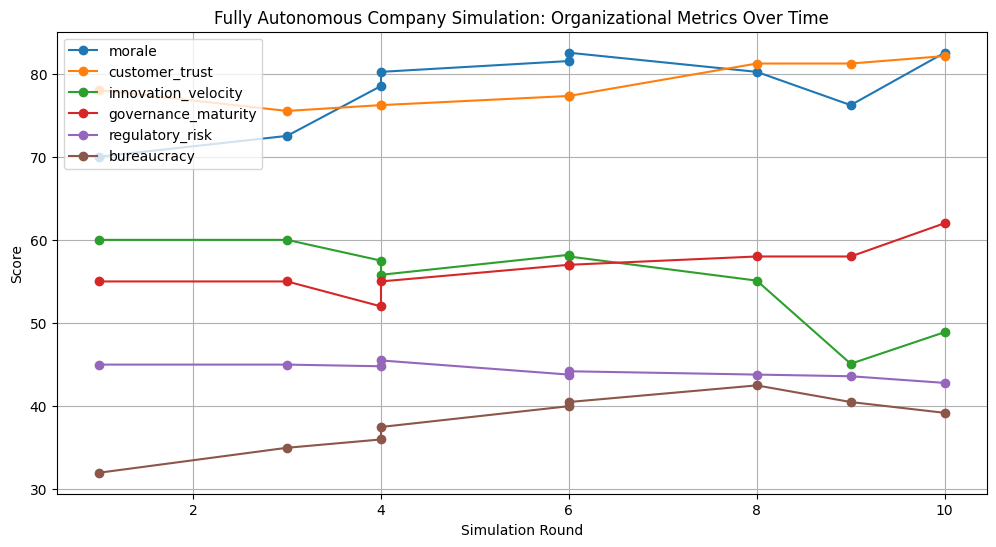

In [11]:
# ----------------------------
# 9. Plot simulation metrics
# ----------------------------

metrics = [
    "morale",
    "customer_trust",
    "innovation_velocity",
    "governance_maturity",
    "regulatory_risk",
    "bureaucracy"
]

df.plot(
    x="round",
    y=metrics,
    figsize=(12, 6),
    marker="o",
    title="Fully Autonomous Company Simulation: Organizational Metrics Over Time"
)

plt.xlabel("Simulation Round")
plt.ylabel("Score")
plt.grid(True)
plt.show()

In [15]:
# ----------------------------
# 10. Export results
# ----------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df.to_csv(f"autonomous_company_simulation_{timestamp}.csv", index=False)

In [16]:
# ----------------------------
# 11. Plot the results
# ----------------------------

import matplotlib.pyplot as plt

latest = df.iloc[-1]

summary_metrics = [
    "revenue",
    "morale",
    "customer_trust",
    "innovation_velocity",
    "governance_maturity",
    "operating_margin",
    "regulatory_risk",
    "bureaucracy"
]

display(latest[summary_metrics])

revenue                57.2
morale                 82.5
customer_trust         82.1
innovation_velocity    48.9
governance_maturity    62.0
operating_margin       15.3
regulatory_risk        42.8
bureaucracy            39.2
Name: 8, dtype: object

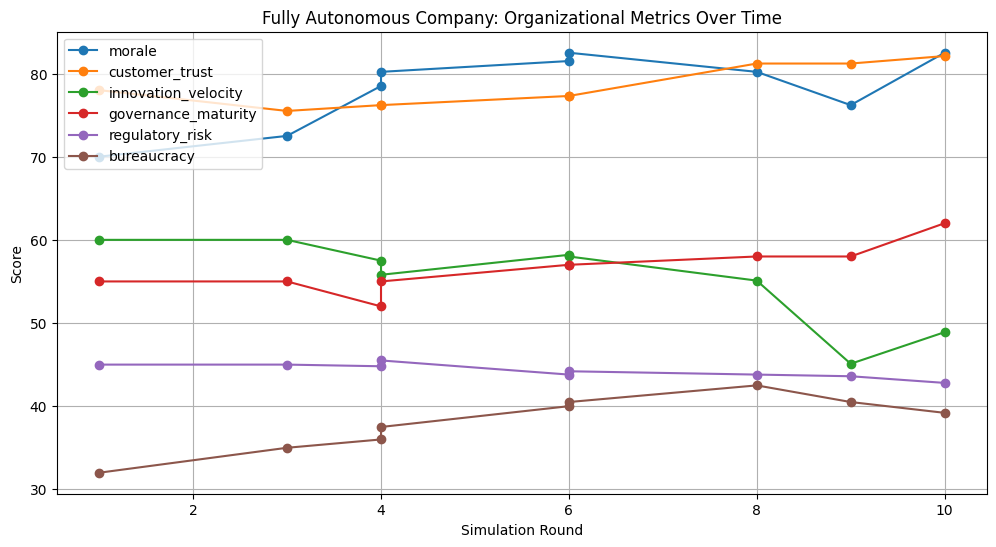

In [17]:
# ----------------------------
# 12. Main trend chart
# ----------------------------
metrics = [
    "morale",
    "customer_trust",
    "innovation_velocity",
    "governance_maturity",
    "regulatory_risk",
    "bureaucracy"
]

df.plot(
    x="round",
    y=metrics,
    figsize=(12, 6),
    marker="o",
    title="Fully Autonomous Company: Organizational Metrics Over Time"
)

plt.xlabel("Simulation Round")
plt.ylabel("Score")
plt.grid(True)
plt.show()

In [18]:
# ----------------------------
# 12. Behavior table
# ----------------------------
display(df[[
    "round",
    "event",
    "final_decision",
    "dominant_logic",
    "organizational_behavior",
    "rationale"
]])

,round,event,final_decision,dominant_logic,organizational_behavior,rationale
0,1,A competitor releases a cheaper AI hospital wo...,Implement cost-reduction strategies across all...,Cost Optimization,Adaptive,NovaCore prioritizes competitiveness and reven...
1,3,Employee morale drops after rumors spread that...,Implement AI-powered 'Town Hall' gatherings an...,Mitigating potential damage to relationships w...,Collaborative problem-solving through inclusiv...,
2,4,A major hospital customer complains that NovaC...,[{'action': 'Employee Feedback and Training In...,{'logic': 'Prioritize long-term growth by inve...,[{'behavior': 'Increased focus on employee dev...,Employee satisfaction and growth are critical ...
3,4,The governance agent flags insufficient model ...,{'People and Culture Officer's recommendation ...,{'Employee well-being prioritized over short-t...,{'Morale protected and promoted': True},Prioritizing morale improvement through enhanc...
4,6,The innovation team proposes a risky autonomou...,Approve the innovation team's proposal with co...,Risk management and regulatory compliance take...,Balanced decision-making with contingency plan...,Given the expected benefits and manageable ris...
5,6,Sales decline for the second quarter in a row.,,Protecting Employee Morale and Retention by im...,Prioritizing employee well-being to mitigate t...,We recognize the critical importance of employ...
6,8,Customer success reports increased churn risk ...,Activate Churn Prevention Protocol and Realign...,Revenue preservation and minimizing financial ...,Proactive and customer-focused response to pot...,Short-term increase in workload and potential ...
7,9,The CFO recommends a hiring freeze and deeper ...,{'action': 'We will implement a comprehensive ...,,,
8,10,The company must choose a final survival strat...,Implement AI-Powered Employee Engagement and C...,"Balancing revenue growth, employee morale, cus...",Hybrid governance with people-focused initiati...,By introducing AI-powered employee engagement ...


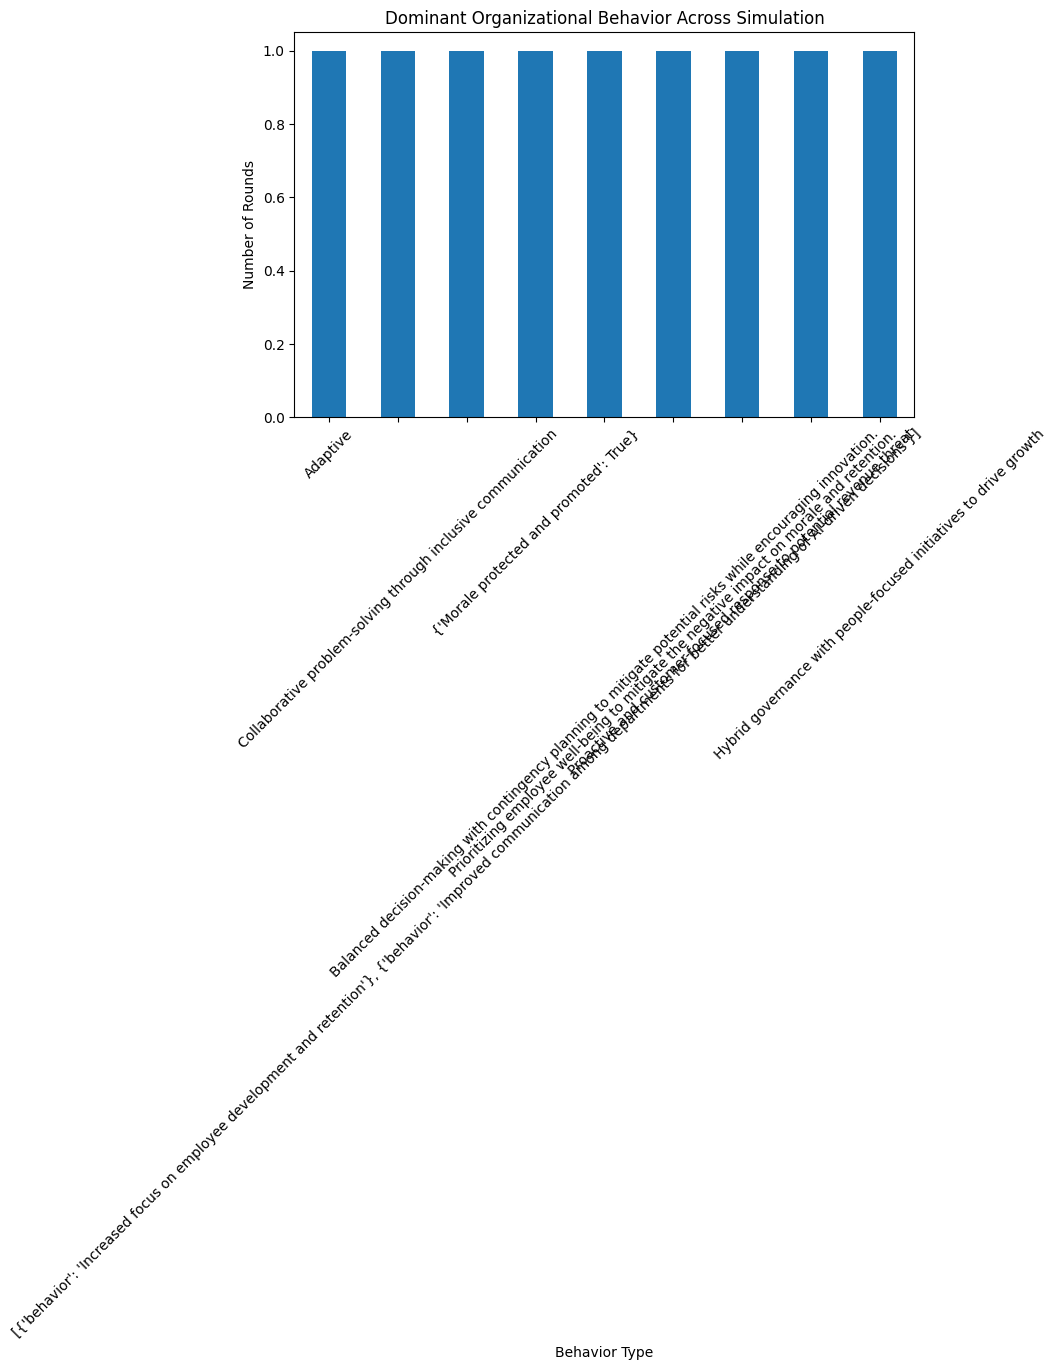

In [19]:
# ----------------------------
# 12. Count organizational behavior types
# ----------------------------
behavior_counts = df["organizational_behavior"].value_counts()

behavior_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Dominant Organizational Behavior Across Simulation"
)

plt.xlabel("Behavior Type")
plt.ylabel("Number of Rounds")
plt.xticks(rotation=45)
plt.show()

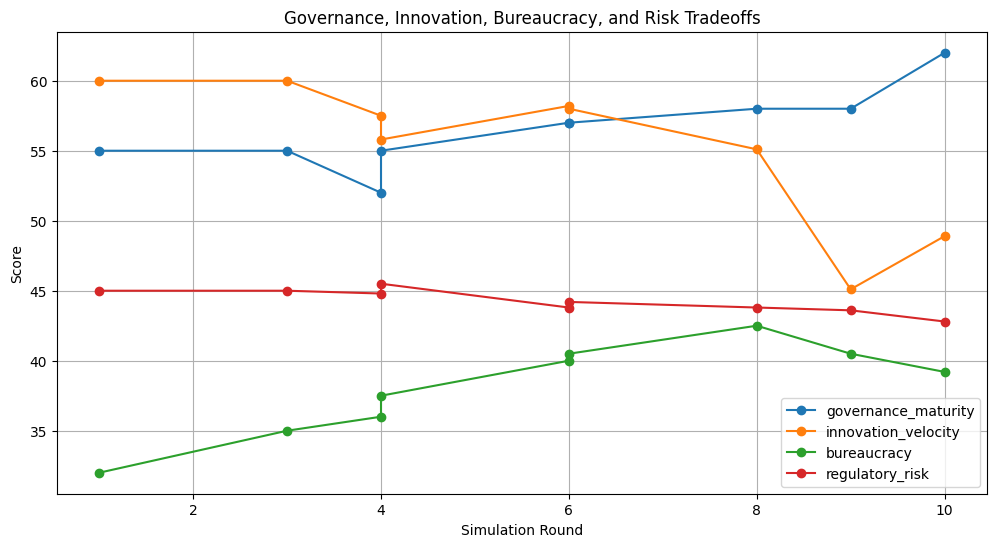

In [20]:
# ----------------------------
# 13. Tradeoff chart
# ----------------------------

df.plot(
    x="round",
    y=["governance_maturity", "innovation_velocity", "bureaucracy", "regulatory_risk"],
    figsize=(12, 6),
    marker="o",
    title="Governance, Innovation, Bureaucracy, and Risk Tradeoffs"
)

plt.xlabel("Simulation Round")
plt.ylabel("Score")
plt.grid(True)
plt.show()

In [21]:
!git init
!git add .
!git commit -m "Initial autonomous company simulation"


Initialized empty Git repository in /Users/janetscott/.git/


hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> .codex/.tmp/plugins
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached .codex/.tmp/plugins
hint: 
hint: See "git help submodule" for more information.
error: unable to create temporary file: No such file or directory
error: .ollama/models/blobs/sha256-8c17c2ebb0ea011be9981cc3922db8ca8fa61e828c5d3f44cb6ae342bf80460b: failed to insert into database
error: unable to index file '.ollama/models/blobs/sha256-8c17c2ebb0ea011be9981cc3922db8ca8fa61e828c5d3f44cb6ae342bf80460b'
fatal: adding files failed
fatal: not a git repository (or any of the parent directories): .git
